# 💳 AI Risk Lab: Fraud Detection using Machine Learning

## 1. Introduction

Fraud detection is a critical problem in financial systems where identifying fraudulent transactions is challenging due to highly imbalanced data.

This notebook presents a comparative study of machine learning models for fraud detection using an imbalanced financial dataset.

## 2. Data Exploration

In this section, we explore the dataset structure, check for missing values, and analyze the class distribution.

The dataset is highly imbalanced, with significantly fewer fraudulent transactions compared to normal ones.

In [38]:
import pandas as pd
df = pd.read_csv("creditcard.csv")

df = df.sample(n=50000, random_state=42)
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
43428,41505.0,-16.526507,8.584972,-18.649853,9.505594,-13.793819,-2.832404,-16.701694,7.517344,-8.507059,...,1.190739,-1.127670,-2.358579,0.673461,-1.413700,-0.462762,-2.018575,-1.042804,364.19,1
49906,44261.0,0.339812,-2.743745,-0.134070,-1.385729,-1.451413,1.015887,-0.524379,0.224060,0.899746,...,-0.213436,-0.942525,-0.526819,-1.156992,0.311211,-0.746647,0.040996,0.102038,520.12,0
29474,35484.0,1.399590,-0.590701,0.168619,-1.029950,-0.539806,0.040444,-0.712567,0.002299,-0.971747,...,0.102398,0.168269,-0.166639,-0.810250,0.505083,-0.232340,0.011409,0.004634,31.00,0
276481,167123.0,-0.432071,1.647895,-1.669361,-0.349504,0.785785,-0.630647,0.276990,0.586025,-0.484715,...,0.358932,0.873663,-0.178642,-0.017171,-0.207392,-0.157756,-0.237386,0.001934,1.50,0
278846,168473.0,2.014160,-0.137394,-1.015839,0.327269,-0.182179,-0.956571,0.043241,-0.160746,0.363241,...,-0.238644,-0.616400,0.347045,0.061561,-0.360196,0.174730,-0.078043,-0.070571,0.89,0


In [39]:
df.shape


(50000, 31)

In [40]:
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

In [41]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [42]:
df['Class'].value_counts()

Class
0    49917
1       83
Name: count, dtype: int64

### Class Distribution

The following visualization highlights the imbalance between normal and fraudulent transactions.

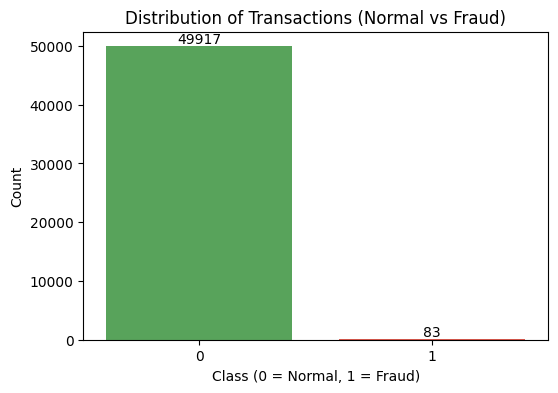

In [43]:
plt.figure(figsize=(6,4))

sns.countplot(x='Class', data=df, hue='Class', palette=['#4CAF50', '#F44336'], legend=False)

plt.title("Distribution of Transactions (Normal vs Fraud)")
plt.xlabel("Class (0 = Normal, 1 = Fraud)")
plt.ylabel("Count")

# Add values on top
for p in plt.gca().patches:
    plt.text(p.get_x() + p.get_width()/2, 
             p.get_height() + 500, 
             int(p.get_height()), 
             ha='center')

plt.show()

## 3. Data Preprocessing

The dataset is prepared for model training by separating features and target variables, splitting into training and testing sets, and scaling the features.

In [44]:
X = df.drop('Class', axis=1)
y = df['Class']

In [45]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [46]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## 4. Model Training

Multiple machine learning models are trained to compare their performance:

- Logistic Regression
- Decision Tree
- Random Forest
- Support Vector Machine (SVM)

In [47]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression()
log_model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [48]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier()
dt_model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [49]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier()
rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [50]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC()
svm_model.fit(X_train, y_train)

,penalty,'l2'
,loss,'squared_hinge'
,dual,'auto'
,tol,0.0001
,C,1.0
,multi_class,'ovr'
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,verbose,0
,random_state,None


In [51]:
log_pred = log_model.predict(X_test)
dt_pred = dt_model.predict(X_test)
rf_pred = rf_model.predict(X_test)
svm_pred = svm_model.predict(X_test)

## 5. Model Evaluation

Models are evaluated using:
- Accuracy
- Precision
- Recall

Since the dataset is imbalanced, precision and recall are more important than accuracy.

In [52]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

In [53]:
models = {
    "Logistic Regression": log_pred,
    "Decision Tree": dt_pred,
    "Random Forest": rf_pred,
    "SVM": svm_pred
}

for name, pred in models.items():
    print(f"{name}")
    print("Accuracy:", accuracy_score(y_test, pred))
    print("Precision:", precision_score(y_test, pred))
    print("Recall:", recall_score(y_test, pred))
    print("-" * 30)

Logistic Regression
Accuracy: 0.9994
Precision: 0.6666666666666666
Recall: 0.5
------------------------------
Decision Tree
Accuracy: 0.9988
Precision: 0.35714285714285715
Recall: 0.625
------------------------------
Random Forest
Accuracy: 0.9996
Precision: 0.8333333333333334
Recall: 0.625
------------------------------
SVM
Accuracy: 0.9996
Precision: 0.8333333333333334
Recall: 0.625
------------------------------


### Performance Comparison Table

In [60]:
results = []

for name, pred in models.items():
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred)
    })

results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,Precision,Recall
0,Logistic Regression,0.9994,0.666667,0.500
1,Decision Tree,0.9988,0.357143,0.625
2,Random Forest,0.9996,0.833333,0.625
3,SVM,0.9996,0.833333,0.625


## 6. Visualizations

Visualizations help in understanding model performance and feature importance.

### Confusion Matrix

This shows how well the model distinguishes between normal and fraudulent transactions.



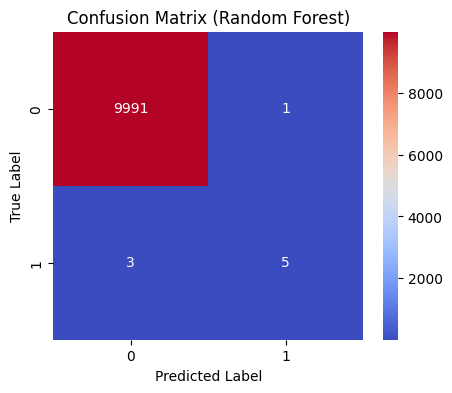

In [55]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(5,4))

sns.heatmap(cm, annot=True, fmt='d', cmap='coolwarm')
plt.title("Confusion Matrix (Random Forest)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

### Model Performance Comparison

This chart compares accuracy, precision, and recall across models.

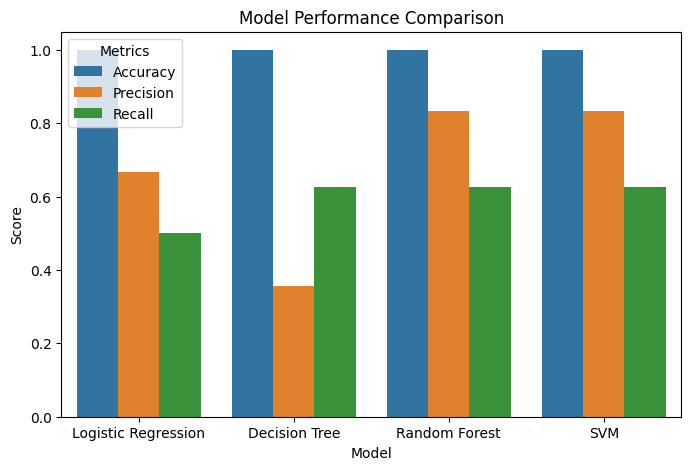

In [56]:
plt.figure(figsize=(8,5))

sns.barplot(data=results_df.melt(id_vars="Model"), 
            x="Model", y="value", hue="variable")

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.legend(title="Metrics")
plt.show()

### Feature Importance

This highlights the most important features used by the Random Forest model.

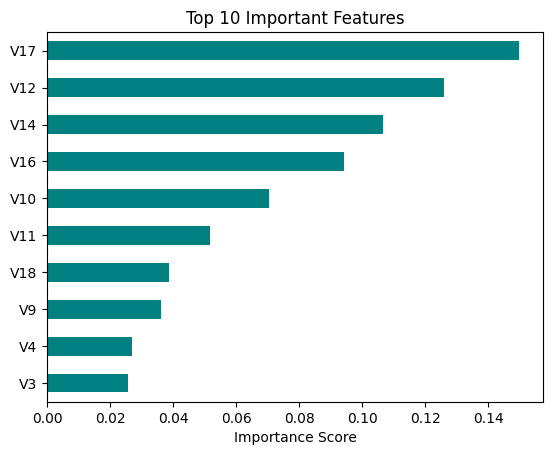

In [57]:
feature_importance.nlargest(10).sort_values().plot(kind='barh', color='teal')

plt.title("Top 10 Important Features")
plt.xlabel("Importance Score")
plt.show()

### ROC Curve Analysis

The ROC curve shows the trade-off between true positive rate and false positive rate.

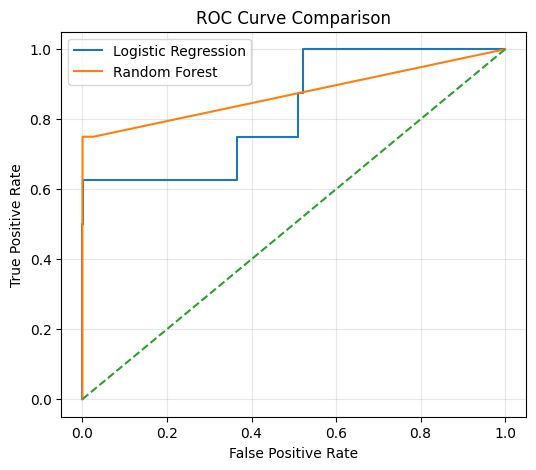

In [58]:
models_probs = {
    "Logistic Regression": log_model.predict_proba(X_test)[:,1],
    "Random Forest": rf_model.predict_proba(X_test)[:,1]
}

plt.figure(figsize=(6,5))

for name, probs in models_probs.items():
    fpr, tpr, _ = roc_curve(y_test, probs)
    plt.plot(fpr, tpr, label=name)

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

### Pairplot Analysis

A subset of features is visualized to understand relationships between variables and how fraud differs from normal transactions.

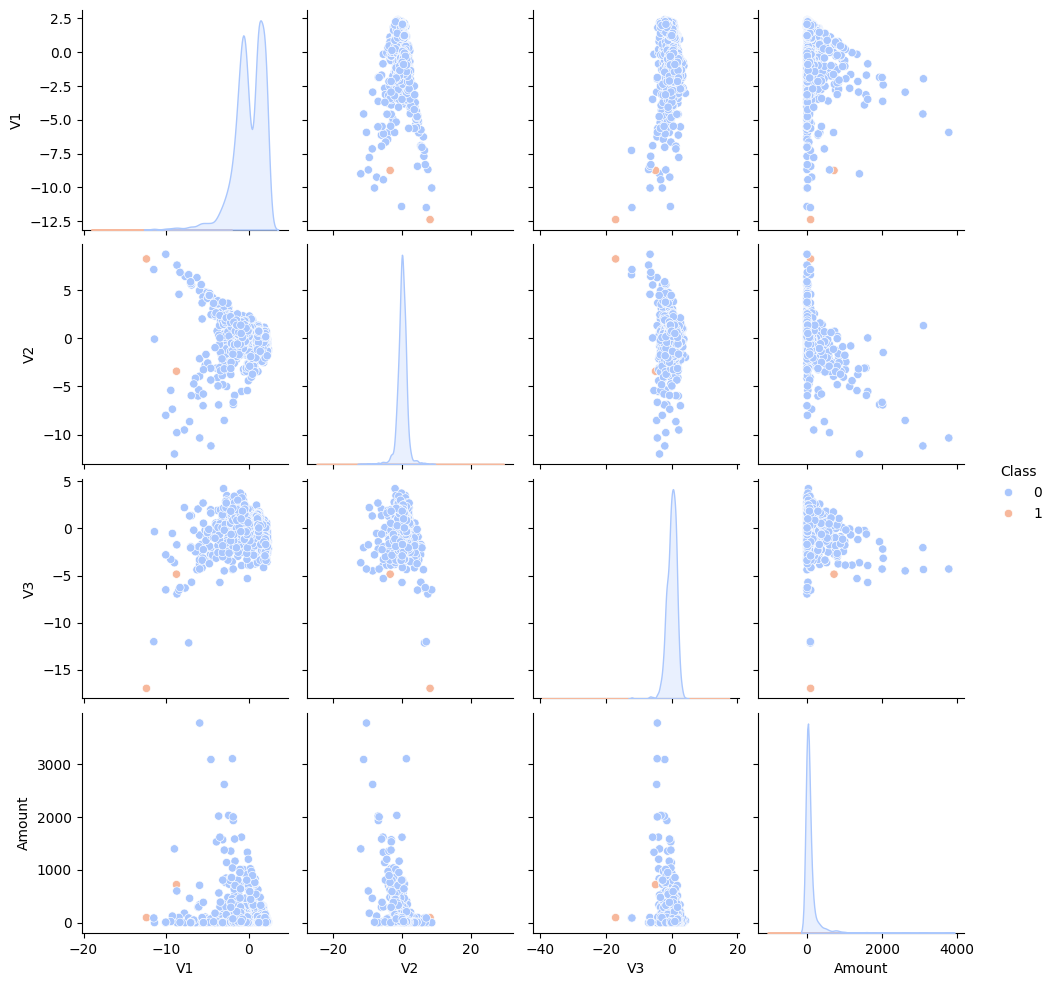

In [59]:
sample_df = df[['V1', 'V2', 'V3', 'Amount', 'Class']].sample(2000)

sns.pairplot(sample_df, hue='Class', palette='coolwarm')
plt.show()

## 7. Conclusion

Random Forest and SVM achieved the best performance by maintaining a strong balance between precision and recall.

Although Logistic Regression showed high accuracy, it failed to detect many fraud cases, making it less suitable for this problem.

### Key Insight
In imbalanced datasets like fraud detection, accuracy alone is not a reliable metric. Precision and recall provide better insight into model performance.

### Future Work
Future improvements could include handling class imbalance using techniques like oversampling or SMOTE, and tuning model hyperparameters for better performance.




This project demonstrates the importance of selecting appropriate evaluation metrics and models for real-world classification problems.